 ## STL Symmetry - MobileNet (CUT_LAYER=0) + K-Fold + GradCAM

In [1]:
import os
import json
import time
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, cohen_kappa_score,
)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
### Nota importante:
# He eliminado ISIC_0028189 del conjunto de train, porque era corrupta.

2026-04-26 18:08:21.804494: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


In [2]:
train_csv  = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/train_onehot.csv"
val_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/val_onehot.csv"
test_csv   = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/test_onehot.csv"
images_dir = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"


IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 3
N_FOLDS     = 5
class_cols  = ["dx_akiec", "dx_bcc", "dx_bkl", "dx_df", "dx_mel", "dx_nv", "dx_vasc"]
class_names = ["2_ejes", "1_eje", "asimetrica"]   #clases de symmetry
CUT_LAYER   = 0

WARMUP_EPOCHS, FT_EPOCHS = 30, 30
WARMUP_LR = 1e-3          # LR warmup (solo heads)
FT_LR     = 5e-5          # LR fine-tuning (todo el modelo descongelado)
TASK_NAME   = "symmetry"   

EXP_DIR = Path("MobileNetV2_STL") / f"exp_{dt.datetime.now():%Y-%m-%d_%H-%M}_{TASK_NAME}_CUT{CUT_LAYER}_{N_FOLDS}fold"
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experimento STL ({TASK_NAME}) en: {EXP_DIR.resolve()}")

Experimento STL (symmetry) en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold


In [3]:
df_train = pd.read_csv(train_csv)
df_val   = pd.read_csv(val_csv)
df_test  = pd.read_csv(test_csv)

# CSV de symmetry (¡importante!)
df_sym   = pd.read_csv("/home/marc/MARIADELMAR_EXPERIMENTS/ham10000_shape_symmetry_ALL.csv")

print(f"CSVs - train: {len(df_train)}  val: {len(df_val)}  test: {len(df_test)}")
print(f"Symmetry CSV - total: {len(df_sym)}")

# Renombrar columna y merge con cada split
df_sym = df_sym.rename(columns={"image": "image_id"})
df_sym = df_sym[["image_id", "shape_symmetry"]]

def merge_with_sym(df, name):
    before = len(df)
    merged = df.merge(df_sym, on="image_id", how="inner")
    lost   = before - len(merged)
    if lost > 0:
        print(f"  [WARN] {name}: perdidas {lost} imágenes sin entrada en symmetry CSV")
    else:
        print(f"  {name}: merge OK, 0 imágenes perdidas")
    return merged

print("\nMerge con CSV de symmetry:")
df_train = merge_with_sym(df_train, "train")
df_val   = merge_with_sym(df_val,   "val")
df_test  = merge_with_sym(df_test,  "test")

for df in (df_train, df_val, df_test):
    df["filepath"] = df["image_id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))

# Etiquetas de symmetry (one-hot)
def to_onehot_sym(df):
    y = np.zeros((len(df), NUM_CLASSES), dtype="float32")
    y[np.arange(len(df)), df["shape_symmetry"].values] = 1.0
    return y

y_train = to_onehot_sym(df_train)
y_val   = to_onehot_sym(df_val)
y_test  = to_onehot_sym(df_test)

df_trainval    = pd.concat([df_train, df_val], ignore_index=True)
y_trainval     = np.concatenate([y_train, y_val], axis=0)
y_trainval_int = np.argmax(y_trainval, axis=1)
y_test_int     = np.argmax(y_test, axis=1)

print("\n" + "="*60)
print(f"DISTRIBUCIÓN DE ETIQUETAS - tarea: {TASK_NAME}")
print("="*60)
for i, c in enumerate(class_names):
    n = (y_trainval_int == i).sum()
    print(f"  {c:<12} {n:>5}  ({100*n/len(y_trainval_int):.1f}%)")
print(f"\nTest set fijo: {len(df_test)} imágenes")

# Class weights balanceados
cw = compute_class_weight(class_weight="balanced",
                           classes=np.arange(NUM_CLASSES),
                           y=y_trainval_int)
CW = tf.constant(cw, dtype=tf.float32)
class_weight_dict = {i: float(cw[i]) for i in range(NUM_CLASSES)}
print(f"\nClass weights: {cw.round(3)}")

CSVs — train: 6008  val: 2003  test: 2003
Symmetry CSV — total: 10015

Merge con CSV de symmetry:
  train: merge OK, 0 imágenes perdidas
  val: merge OK, 0 imágenes perdidas
  test: merge OK, 0 imágenes perdidas

DISTRIBUCIÓN DE ETIQUETAS — tarea: symmetry
  2_ejes        4785  (59.7%)
  1_eje         2468  (30.8%)
  asimetrica     758  (9.5%)

Test set fijo: 2003 imágenes

Class weights: [0.558 1.082 3.523]


2026-04-26 18:08:22.852330: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1
2026-04-26 18:08:22.882574: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0000:05:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.91GiB deviceMemoryBandwidth: 451.17GiB/s
2026-04-26 18:08:22.882621: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1
2026-04-26 18:08:22.884439: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-04-26 18:08:22.886178: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcufft.so.10
2026-04-26 18:08:22.886466: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcurand.so

In [4]:
def load_image(filepath, y):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, y

def load_image_aug(filepath, y):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, y

def make_dataset(filepaths, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, y))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(load_image_aug if training else load_image, num_parallel_calls=15)
    ds = ds.batch(BATCH_SIZE).prefetch(50)
    return ds

test_ds = make_dataset(df_test["filepath"].values, y_test, training=False)

print("Sanity check:")
for imgs, y in test_ds.take(1):
    print(f"  imgs: {imgs.shape}  y: {y.shape}")

Sanity check:
  imgs: (32, 224, 224, 3)  y: (32, 3)


In [5]:
def build_model():
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False, weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    )
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_image")
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = tf.keras.layers.Dense(256, activation="relu", name="shared_dense")(x)
    x = tf.keras.layers.Dropout(0.3, name="shared_dropout")(x)
    out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax",
                                 name=f"head_{TASK_NAME}")(x)
    model = tf.keras.Model(inputs=inputs, outputs=out, name=f"STL_MobileNetV2_{TASK_NAME}")
    return model, base_model

# Visualización
_tmp_m, _tmp_b = build_model()
_tmp_m.summary()
tf.keras.utils.plot_model(_tmp_m, to_file=str(EXP_DIR / "00_model_architecture.png"),
                           show_shapes=True, show_layer_names=True,
                           expand_nested=True, dpi=150)
del _tmp_m, _tmp_b
tf.keras.backend.clear_session()

Model: "STL_MobileNetV2_symmetry"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 224, 224, 3)]     0         
_________________________________________________________________
mobilenetv2_1.00_224 (Functi (None, 7, 7, 1280)        2257984   
_________________________________________________________________
gap (GlobalAveragePooling2D) (None, 1280)              0         
_________________________________________________________________
shared_dense (Dense)         (None, 256)               327936    
_________________________________________________________________
shared_dropout (Dropout)     (None, 256)               0         
_________________________________________________________________
head_symmetry (Dense)        (None, 3)                 771       
Total params: 2,586,691
Trainable params: 328,707
Non-trainable params: 2,257,984
__________________________

In [7]:
def unfreeze_from(base_model, cut_layer):
    base_model.trainable = True
    for layer in base_model.layers:
        layer.trainable = False
    for i, layer in enumerate(base_model.layers):
        if i >= cut_layer:
            layer.trainable = True
    trainable = sum(l.count_params() for l in base_model.layers if l.trainable)
    total     = base_model.count_params()
    print(f"cut_layer={cut_layer} -> {trainable:,}/{total:,} params trainable "
          f"({100*trainable/total:.1f}%)")

print("Helper unfreeze listo.")

Helper unfreeze listo.


In [8]:
def train_one_fold(fold_idx, train_idx, val_idx, fold_dir):
    fold_dir.mkdir(exist_ok=True)
    print(f"\n{'='*70}\nFOLD {fold_idx}/{N_FOLDS} - STL {TASK_NAME}\n{'='*70}")

    df_tr = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_vl = df_trainval.iloc[val_idx].reset_index(drop=True)
    y_tr = to_onehot_sym(df_tr)   
    y_vl = to_onehot_sym(df_vl)   
    print(f"  train={len(df_tr)}  val={len(df_vl)}  test(fijo)={len(df_test)}")

    train_ds = make_dataset(df_tr["filepath"].values, y_tr, training=True)
    val_ds   = make_dataset(df_vl["filepath"].values, y_vl, training=False)

    model, base_model = build_model()

    #FASE 1: WARMUP 
    print(f"\n--- FASE 1: warmup (head only, LR={WARMUP_LR}) ---")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=WARMUP_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    callbacks_warmup = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=7, min_delta=0.005,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]
    t0 = time.time()
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=WARMUP_EPOCHS,
                    class_weight=class_weight_dict,
                    callbacks=callbacks_warmup, verbose=2)
    t_warmup = time.time() - t0

    #FASE 2: FINE-TUNING 
    print(f"\n--- FASE 2: fine-tuning (CUT_LAYER={CUT_LAYER}, LR={FT_LR}) ---")
    unfreeze_from(base_model, CUT_LAYER)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=FT_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    callbacks_ft = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=8, min_delta=0.005,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]
    t0 = time.time()
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=FT_EPOCHS,
                    class_weight=class_weight_dict,
                    callbacks=callbacks_ft, verbose=2)
    t_ft = time.time() - t0

    #History combinada 
    h1_dict = h1.history
    h2_dict = h2.history
    history = {k: list(h1_dict.get(k, [])) + list(h2_dict.get(k, [])) for k in h1_dict}
    pd.DataFrame(history).to_csv(fold_dir / "history.csv", index=False)

    #Evaluación sobre test 
    print(f"\n--- Evaluación sobre test ({len(df_test)} imgs) ---")
    t0 = time.time()
    y_pred_proba = model.predict(test_ds, verbose=0)
    t_predict = time.time() - t0
    y_pred_int = np.argmax(y_pred_proba, axis=1)

    metrics = {
        "fold":           fold_idx,
        "time_warmup_s":  round(t_warmup, 1),
        "time_ft_s":      round(t_ft, 1),
        "time_total_s":   round(t_warmup + t_ft, 1),
        "time_predict_s": round(t_predict, 2),
        "epochs_warmup":  len(h1_dict["loss"]),
        "epochs_ft":      len(h2_dict["loss"]),
        "len_warmup":     len(h1_dict["loss"]),
        f"{TASK_NAME}_acc":             float((y_test_int == y_pred_int).mean()),
        f"{TASK_NAME}_balanced_acc":    float(balanced_accuracy_score(y_test_int, y_pred_int)),
        f"{TASK_NAME}_precision_macro": float(precision_score(y_test_int, y_pred_int, average="macro", zero_division=0)),   
        f"{TASK_NAME}_recall_macro":    float(recall_score(y_test_int, y_pred_int, average="macro", zero_division=0)),       
        f"{TASK_NAME}_f1_macro":        float(f1_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
        f"{TASK_NAME}_f1_weighted":     float(f1_score(y_test_int, y_pred_int, average="weighted", zero_division=0)),
        f"{TASK_NAME}_kappa":           float(cohen_kappa_score(y_test_int, y_pred_int)),
    }
    try:
        y_true_onehot = np.eye(NUM_CLASSES)[y_test_int]
        metrics[f"{TASK_NAME}_auc_macro"] = float(
            roc_auc_score(y_true_onehot, y_pred_proba, multi_class="ovr", average="macro"))
    except Exception:
        metrics[f"{TASK_NAME}_auc_macro"] = float("nan")

    (fold_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))

    rpt = classification_report(y_test_int, y_pred_int,
                                 target_names=class_names, digits=4)
    (fold_dir / f"classification_report_{TASK_NAME}.txt").write_text(rpt)
    print(f"\n--- {TASK_NAME.upper()} ---\n{rpt}")

    cm = confusion_matrix(y_test_int, y_pred_int)
    np.save(fold_dir / f"confusion_matrix_{TASK_NAME}.npy", cm)
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
    ax.set_title(f"Fold {fold_idx} - {TASK_NAME} (test)")
    plt.tight_layout()
    plt.savefig(fold_dir / f"confusion_matrix_{TASK_NAME}.png", dpi=100)
    plt.show()

    model.save_weights(str(fold_dir / "best_weights"), save_format="tf")
    print(f"  Pesos guardados en: {fold_dir / 'best_weights'}")

    return {
        "metrics":      metrics,
        "y_pred_int":   y_pred_int,
        "y_pred_proba": y_pred_proba,
        "h1_history":   h1_dict,
        "h2_history":   h2_dict,
    }

print("train_one_fold STL listo.")

train_one_fold STL listo.



FOLD 1/5 — STL symmetry
  train=6408  val=1603  test(fijo)=2003

--- FASE 1: warmup (head only, LR=0.001) ---
Epoch 1/30


2026-04-26 18:08:32.145002: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-04-26 18:08:32.422544: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudnn.so.7


201/201 - 10s - loss: 1.1334 - accuracy: 0.4206 - val_loss: 1.0118 - val_accuracy: 0.4872
Epoch 2/30
201/201 - 9s - loss: 1.0267 - accuracy: 0.4774 - val_loss: 0.9051 - val_accuracy: 0.5777
Epoch 3/30
201/201 - 9s - loss: 0.9905 - accuracy: 0.4994 - val_loss: 0.9706 - val_accuracy: 0.5009
Epoch 4/30
201/201 - 9s - loss: 0.9901 - accuracy: 0.5075 - val_loss: 0.9884 - val_accuracy: 0.4978
Epoch 5/30

Epoch 00005: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
201/201 - 9s - loss: 0.9669 - accuracy: 0.5059 - val_loss: 0.9526 - val_accuracy: 0.5197
Epoch 6/30
201/201 - 9s - loss: 0.9332 - accuracy: 0.5351 - val_loss: 1.0560 - val_accuracy: 0.4361
Epoch 7/30
201/201 - 9s - loss: 0.9213 - accuracy: 0.5400 - val_loss: 0.9994 - val_accuracy: 0.4953
Epoch 8/30

Epoch 00008: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
201/201 - 9s - loss: 0.9113 - accuracy: 0.5442 - val_loss: 0.9598 - val_accuracy: 0.5109
Epoch 9/30
Restoring model weights from the end 

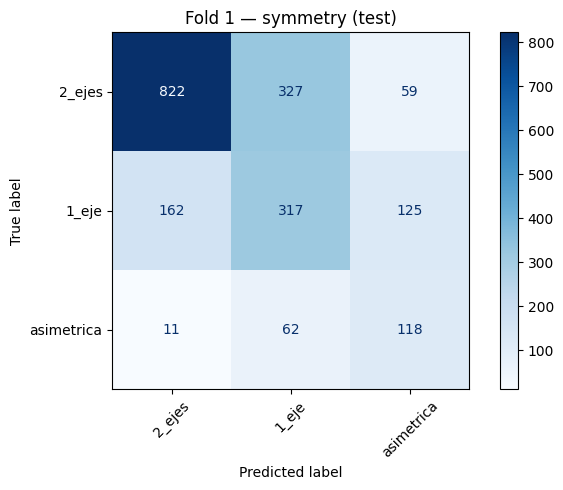

  Pesos guardados en: MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold/fold_1/best_weights

FOLD 2/5 — STL symmetry
  train=6409  val=1602  test(fijo)=2003

--- FASE 1: warmup (head only, LR=0.001) ---
Epoch 1/30
201/201 - 10s - loss: 1.1213 - accuracy: 0.4292 - val_loss: 0.9903 - val_accuracy: 0.4625
Epoch 2/30
201/201 - 9s - loss: 1.0154 - accuracy: 0.4876 - val_loss: 1.0357 - val_accuracy: 0.4482
Epoch 3/30
201/201 - 9s - loss: 0.9903 - accuracy: 0.4892 - val_loss: 1.0028 - val_accuracy: 0.4669
Epoch 4/30

Epoch 00004: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
201/201 - 9s - loss: 0.9733 - accuracy: 0.5024 - val_loss: 1.1358 - val_accuracy: 0.4139
Epoch 5/30
201/201 - 9s - loss: 0.9444 - accuracy: 0.5233 - val_loss: 1.0327 - val_accuracy: 0.4488
Epoch 6/30
201/201 - 9s - loss: 0.9269 - accuracy: 0.5205 - val_loss: 0.9540 - val_accuracy: 0.5169
Epoch 7/30
201/201 - 9s - loss: 0.9204 - accuracy: 0.5386 - val_loss: 0.9508 - val_accuracy: 0.5081
Epoch 8/

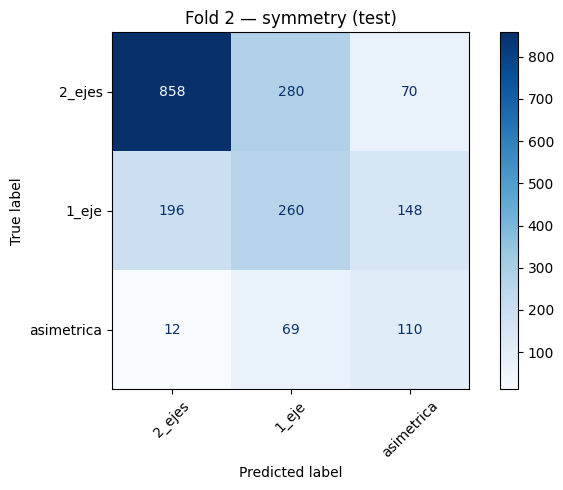

  Pesos guardados en: MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold/fold_2/best_weights

FOLD 3/5 — STL symmetry
  train=6409  val=1602  test(fijo)=2003

--- FASE 1: warmup (head only, LR=0.001) ---
Epoch 1/30
201/201 - 10s - loss: 1.1289 - accuracy: 0.4358 - val_loss: 0.9699 - val_accuracy: 0.5119
Epoch 2/30
201/201 - 9s - loss: 1.0247 - accuracy: 0.4806 - val_loss: 1.0251 - val_accuracy: 0.5006
Epoch 3/30
201/201 - 9s - loss: 0.9864 - accuracy: 0.4985 - val_loss: 0.9398 - val_accuracy: 0.5212
Epoch 4/30
201/201 - 9s - loss: 0.9738 - accuracy: 0.4999 - val_loss: 0.9318 - val_accuracy: 0.5474
Epoch 5/30
201/201 - 9s - loss: 0.9690 - accuracy: 0.5144 - val_loss: 0.9481 - val_accuracy: 0.5362
Epoch 6/30
201/201 - 9s - loss: 0.9468 - accuracy: 0.5271 - val_loss: 0.8480 - val_accuracy: 0.5905
Epoch 7/30
201/201 - 9s - loss: 0.9468 - accuracy: 0.5336 - val_loss: 0.9142 - val_accuracy: 0.5449
Epoch 8/30
201/201 - 9s - loss: 0.9135 - accuracy: 0.5416 - val_loss: 1.0320 - val_accura

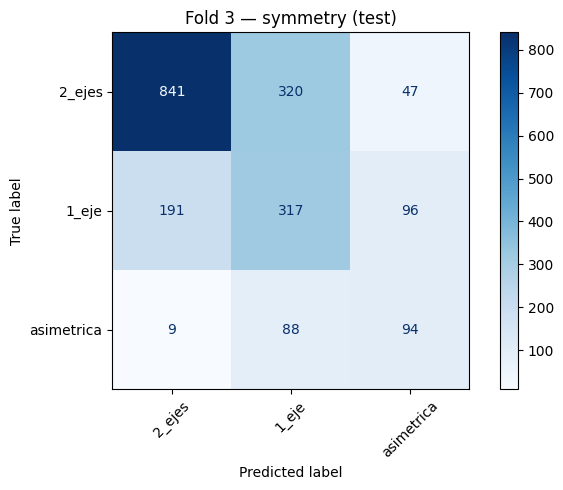

  Pesos guardados en: MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold/fold_3/best_weights

FOLD 4/5 — STL symmetry
  train=6409  val=1602  test(fijo)=2003

--- FASE 1: warmup (head only, LR=0.001) ---
Epoch 1/30
201/201 - 10s - loss: 1.1389 - accuracy: 0.4227 - val_loss: 1.0101 - val_accuracy: 0.4563
Epoch 2/30
201/201 - 10s - loss: 1.0070 - accuracy: 0.4907 - val_loss: 1.0297 - val_accuracy: 0.4600
Epoch 3/30
201/201 - 9s - loss: 0.9895 - accuracy: 0.4965 - val_loss: 1.1501 - val_accuracy: 0.3683
Epoch 4/30

Epoch 00004: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
201/201 - 9s - loss: 0.9776 - accuracy: 0.4980 - val_loss: 1.0295 - val_accuracy: 0.4419
Epoch 5/30
201/201 - 9s - loss: 0.9418 - accuracy: 0.5171 - val_loss: 1.0560 - val_accuracy: 0.4395
Epoch 6/30
201/201 - 10s - loss: 0.9296 - accuracy: 0.5350 - val_loss: 1.0052 - val_accuracy: 0.4600
Epoch 7/30
201/201 - 9s - loss: 0.9163 - accuracy: 0.5316 - val_loss: 0.9669 - val_accuracy: 0.4944
Epoch 

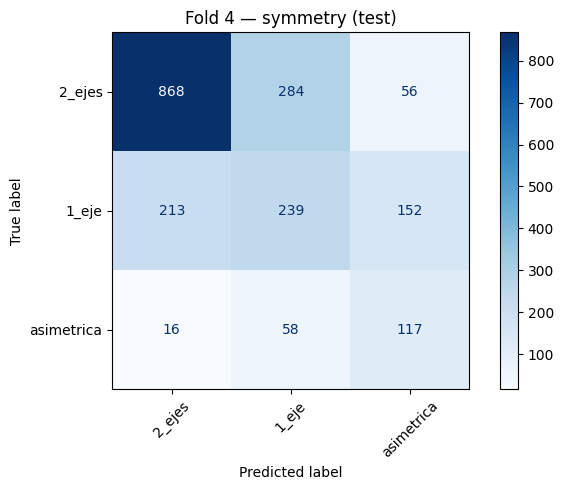

  Pesos guardados en: MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold/fold_4/best_weights

FOLD 5/5 — STL symmetry
  train=6409  val=1602  test(fijo)=2003

--- FASE 1: warmup (head only, LR=0.001) ---
Epoch 1/30
201/201 - 10s - loss: 1.1060 - accuracy: 0.4495 - val_loss: 0.9711 - val_accuracy: 0.5225
Epoch 2/30
201/201 - 10s - loss: 0.9961 - accuracy: 0.4846 - val_loss: 0.9711 - val_accuracy: 0.5119
Epoch 3/30
201/201 - 9s - loss: 0.9853 - accuracy: 0.4985 - val_loss: 1.0464 - val_accuracy: 0.4295
Epoch 4/30

Epoch 00004: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
201/201 - 9s - loss: 0.9732 - accuracy: 0.5063 - val_loss: 1.0599 - val_accuracy: 0.4444
Epoch 5/30
201/201 - 9s - loss: 0.9370 - accuracy: 0.5300 - val_loss: 0.9196 - val_accuracy: 0.5343
Epoch 6/30
201/201 - 9s - loss: 0.9165 - accuracy: 0.5319 - val_loss: 0.9747 - val_accuracy: 0.5050
Epoch 7/30
201/201 - 9s - loss: 0.9104 - accuracy: 0.5394 - val_loss: 1.0063 - val_accuracy: 0.4682
Epoch 8

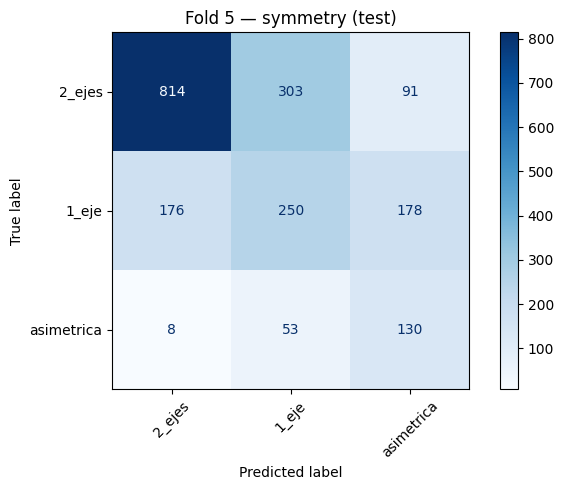

  Pesos guardados en: MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold/fold_5/best_weights

*** Experimento STL symmetry completo en 62.1 min ***

RESUMEN ENTRE 5 FOLDS — STL symmetry
                                mean      median        std
time_warmup_s             141.340000  127.900000  39.009140
time_ft_s                 599.060000  606.500000  91.247482
time_total_s              740.420000  767.700000  63.829633
time_predict_s              2.458000    2.430000   0.138456
epochs_warmup              14.400000   13.000000   4.098780
epochs_ft                  16.600000   17.000000   2.701851
len_warmup                 14.400000   13.000000   4.098780
symmetry_acc                0.614578    0.613080   0.012591
symmetry_balanced_acc       0.583206    0.575601   0.015534
symmetry_precision_macro    0.532759    0.522391   0.017207
symmetry_recall_macro       0.583206    0.575601   0.015534
symmetry_f1_macro           0.545481    0.536670   0.016298
symmetry_f1_weighted        

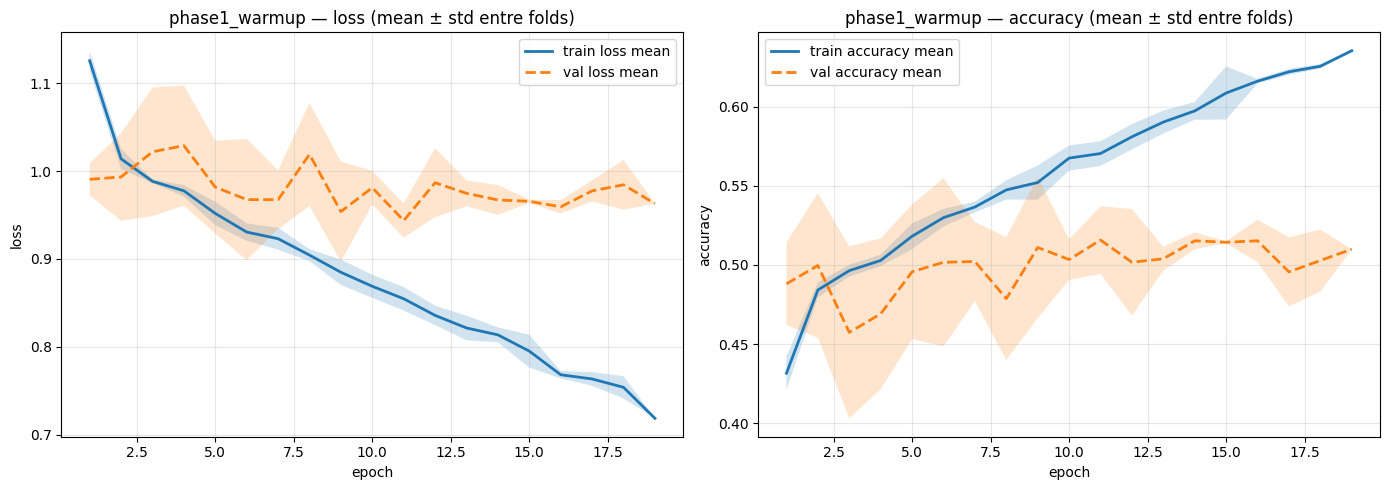


>>> Fase 2 (fine-tuning)


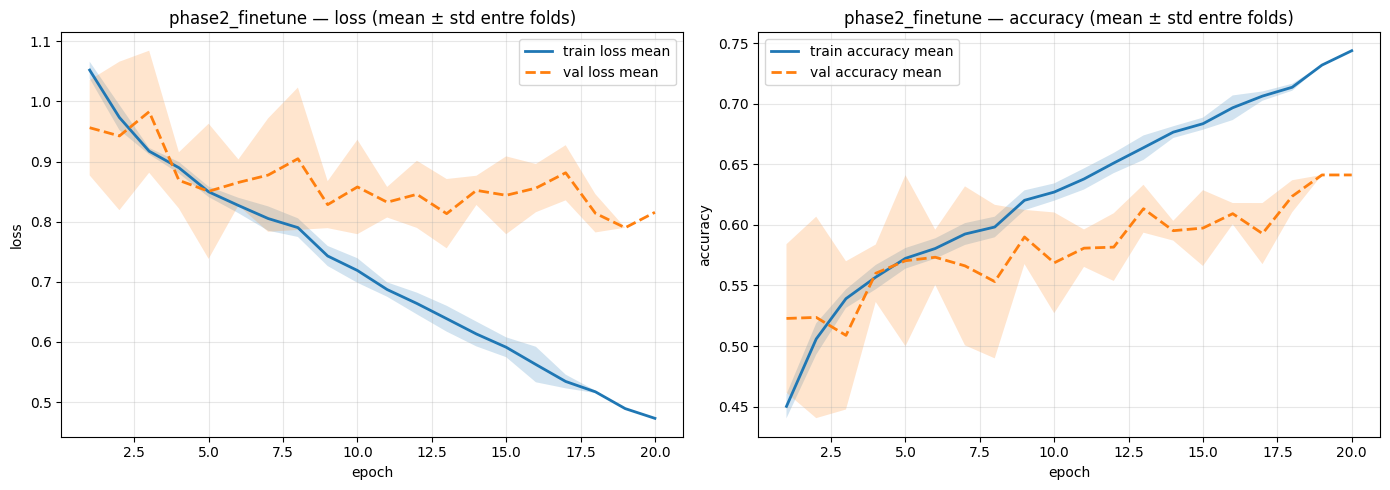


>>> Entrenamiento completo (warmup + FT combinados)


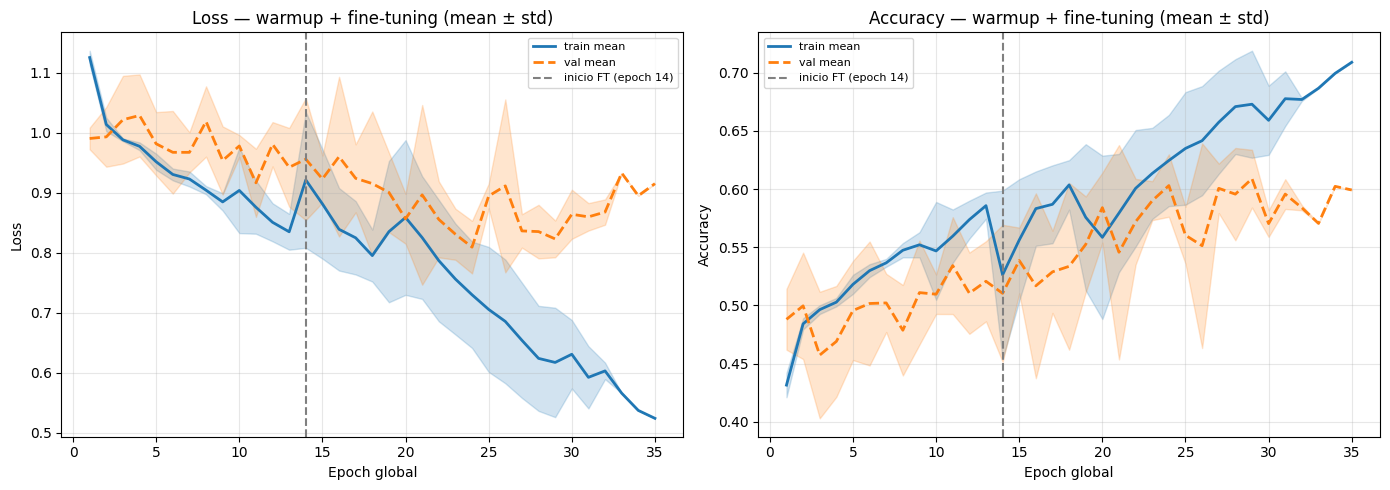

  Gráfica conjunta guardada: MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold/training_plots_cv/combined_full_training.png

>>> Matriz de confusión agregada entre folds


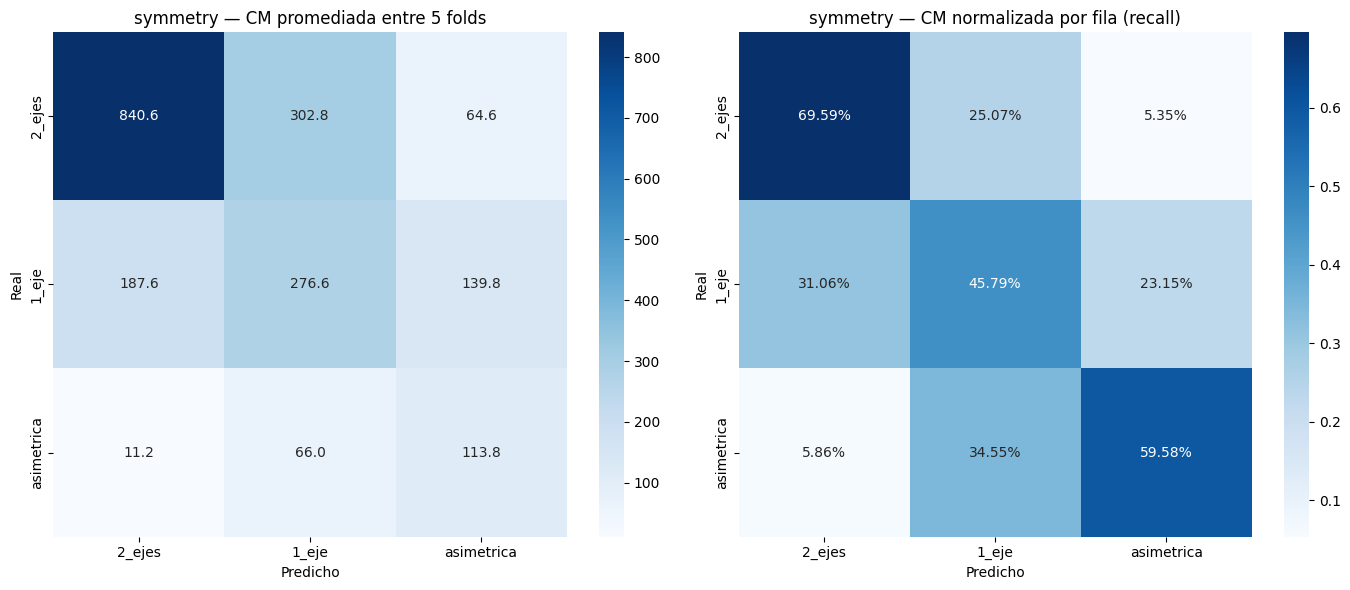

  Guardado: MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold/confusion_matrix_symmetry_aggregated.png


In [9]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
all_fold_metrics = []
histories_warmup = []
histories_ft     = []
t_exp_start      = time.time()

for fold_idx, (train_idx, val_idx) in enumerate(
        skf.split(np.zeros(len(df_trainval)), y_trainval_int), 1):
    fold_dir = EXP_DIR / f"fold_{fold_idx}"
    result   = train_one_fold(fold_idx, train_idx, val_idx, fold_dir)
    all_fold_metrics.append(result["metrics"])
    histories_warmup.append(result["h1_history"])
    histories_ft.append(result["h2_history"])
    del result
    tf.keras.backend.clear_session()

t_exp_total = time.time() - t_exp_start
print(f"\n{'='*70}")
print(f"*** Experimento STL {TASK_NAME} completo en {t_exp_total/60:.1f} min ***")
print(f"{'='*70}")

df_metrics = pd.DataFrame(all_fold_metrics)
df_metrics.to_csv(EXP_DIR / "all_folds_metrics.csv", index=False)

# Summary con mediana
numeric  = [c for c in df_metrics.columns
            if c != "fold" and pd.api.types.is_numeric_dtype(df_metrics[c])]
summary  = df_metrics[numeric].agg(["mean", "median", "std"]).T
summary.columns = ["mean", "median", "std"]
summary["mean±std"] = summary.apply(
    lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
summary.to_csv(EXP_DIR / "summary_mean_median_std.csv")

print("\n" + "="*70)
print(f"RESUMEN ENTRE {N_FOLDS} FOLDS - STL {TASK_NAME}")
print("="*70)
print(summary[["mean", "median", "std"]])
print(f"\nGuardado en: {EXP_DIR}")


#Funciones de curvas 
def _hist_to_dict(h):
    return h.history if hasattr(h, "history") else h

def _pad_to_len(arr, max_len):
    arr = np.asarray(arr, dtype=np.float32)
    out = np.full((max_len,), np.nan, dtype=np.float32)
    out[:min(len(arr), max_len)] = arr[:min(len(arr), max_len)]
    return out

def _stack_metric(histories, key):
    hs      = [_hist_to_dict(h) for h in histories]
    lens    = [len(h.get(key, [])) for h in hs]
    max_len = max(lens) if lens else 0
    if max_len == 0:
        return np.empty((0, 0), dtype=np.float32), 0
    stacked = np.vstack([_pad_to_len(h.get(key, []), max_len) for h in hs]).astype(np.float32)
    return stacked, max_len


def plot_cv_mean_std(histories, save_dir, prefix, band_alpha=0.20):
    os.makedirs(save_dir, exist_ok=True)
    keys = {"loss": ("loss", "val_loss"), "accuracy": ("accuracy", "val_accuracy")}
    stacked, max_len = {}, 0
    for name, (k_tr, k_va) in keys.items():
        tr, ml = _stack_metric(histories, k_tr)
        va, _  = _stack_metric(histories, k_va)
        stacked[name] = (tr, va)
        max_len = max(max_len, ml)
    epochs = np.arange(1, max_len + 1)

    def mean_std(x):
        if x.size == 0:
            return np.full((max_len,), np.nan), np.full((max_len,), np.nan)
        return np.nanmean(x, axis=0), np.nanstd(x, axis=0)

    plt.figure(figsize=(14, 5))
    for i, name in enumerate(["loss", "accuracy"], 1):
        tr, va = stacked[name]
        m_tr, s_tr = mean_std(tr); m_va, s_va = mean_std(va)
        plt.subplot(1, 2, i)
        plt.plot(epochs, m_tr, linewidth=2, label=f"train {name} mean")
        plt.fill_between(epochs, m_tr - s_tr, m_tr + s_tr, alpha=band_alpha)
        plt.plot(epochs, m_va, linewidth=2, linestyle="--", label=f"val {name} mean")
        plt.fill_between(epochs, m_va - s_va, m_va + s_va, alpha=band_alpha)
        plt.title(f"{prefix} - {name} (mean ± std entre folds)")
        plt.xlabel("epoch"); plt.ylabel(name)
        plt.grid(True, alpha=0.3); plt.legend()
    plt.tight_layout()
    fig_path = os.path.join(save_dir, f"{prefix}_cv_mean_std.png")
    plt.savefig(fig_path, dpi=300); plt.show()
    return fig_path


def plot_cv_combined(histories_warmup, histories_ft, save_dir, prefix="combined"):
    """Warmup + FT en un único gráfico con línea divisoria."""
    os.makedirs(save_dir, exist_ok=True)
    histories_full, len_warmups = [], []
    for h1, h2 in zip(histories_warmup, histories_ft):
        combined = {k: list(h1.get(k, [])) + list(h2.get(k, [])) for k in h1}
        histories_full.append(combined)
        len_warmups.append(len(h1["loss"]))
    sep_epoch = int(round(np.mean(len_warmups)))

    keys = {"Loss":     ("loss", "val_loss"),
            "Accuracy": ("accuracy", "val_accuracy")}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (title, (k_tr, k_va)) in zip(axes, keys.items()):
        tr_stk, ml = _stack_metric(histories_full, k_tr)
        va_stk, _  = _stack_metric(histories_full, k_va)
        epochs = np.arange(1, ml + 1)
        m_tr = np.nanmean(tr_stk, axis=0); s_tr = np.nanstd(tr_stk, axis=0)
        m_va = np.nanmean(va_stk, axis=0); s_va = np.nanstd(va_stk, axis=0)

        ax.plot(epochs, m_tr, linewidth=2, label="train mean", color="C0")
        ax.fill_between(epochs, m_tr - s_tr, m_tr + s_tr, alpha=0.2, color="C0")
        ax.plot(epochs, m_va, linewidth=2, linestyle="--", label="val mean", color="C1")
        ax.fill_between(epochs, m_va - s_va, m_va + s_va, alpha=0.2, color="C1")

        ax.axvline(sep_epoch, color="gray", linewidth=1.5, linestyle="--",
                   label=f"inicio FT (epoch {sep_epoch})")
        ax.set_title(f"{title} - warmup + fine-tuning (mean ± std)")
        ax.set_xlabel("Epoch global"); ax.set_ylabel(title)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(save_dir, f"{prefix}_full_training.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"  Gráfica conjunta guardada: {fig_path}")
    return fig_path


#Generar plots 
save_dir = str(EXP_DIR / "training_plots_cv")

print("\n Fase 1 (warmup)")
fig1 = plot_cv_mean_std(histories_warmup, save_dir=save_dir, prefix="phase1_warmup")

print("\n Fase 2 (fine-tuning)")
fig2 = plot_cv_mean_std(histories_ft, save_dir=save_dir, prefix="phase2_finetune")

print("\n Entrenamiento completo (warmup + FT combinados)")
fig_combined = plot_cv_combined(histories_warmup, histories_ft,
                                 save_dir=save_dir, prefix="combined")


#Matriz de confusión agregada 
print("\n Matriz de confusión agregada entre folds")
cms = []
for k in range(1, N_FOLDS + 1):
    cm_path = EXP_DIR / f"fold_{k}" / f"confusion_matrix_{TASK_NAME}.npy"
    if cm_path.exists():
        cms.append(np.load(cm_path))

if cms:
    cm_sum  = np.sum(cms, axis=0)
    cm_mean = cm_sum.astype(float) / len(cms)
    cm_norm = cm_sum.astype(float) / cm_sum.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(cm_mean, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f"{TASK_NAME} - CM promediada entre {len(cms)} folds")
    axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f"{TASK_NAME} - CM normalizada por fila (recall)")
    axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")

    plt.tight_layout()
    out = EXP_DIR / f"confusion_matrix_{TASK_NAME}_aggregated.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Guardado: {out}")
else:
    print("  [AVISO] No se encontraron CMs por fold")

Usando fold 1  (symmetry_balanced_acc=0.6077)
Pesos cargados desde MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold/fold_1/best_weights

Recomputando predicciones del fold seleccionado...

=== GradCAM — Tarea: SYMMETRY (matriz por clase con máscaras) ===
  Guardado: MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold/gradcam/gradcam_symmetry_by_class.png


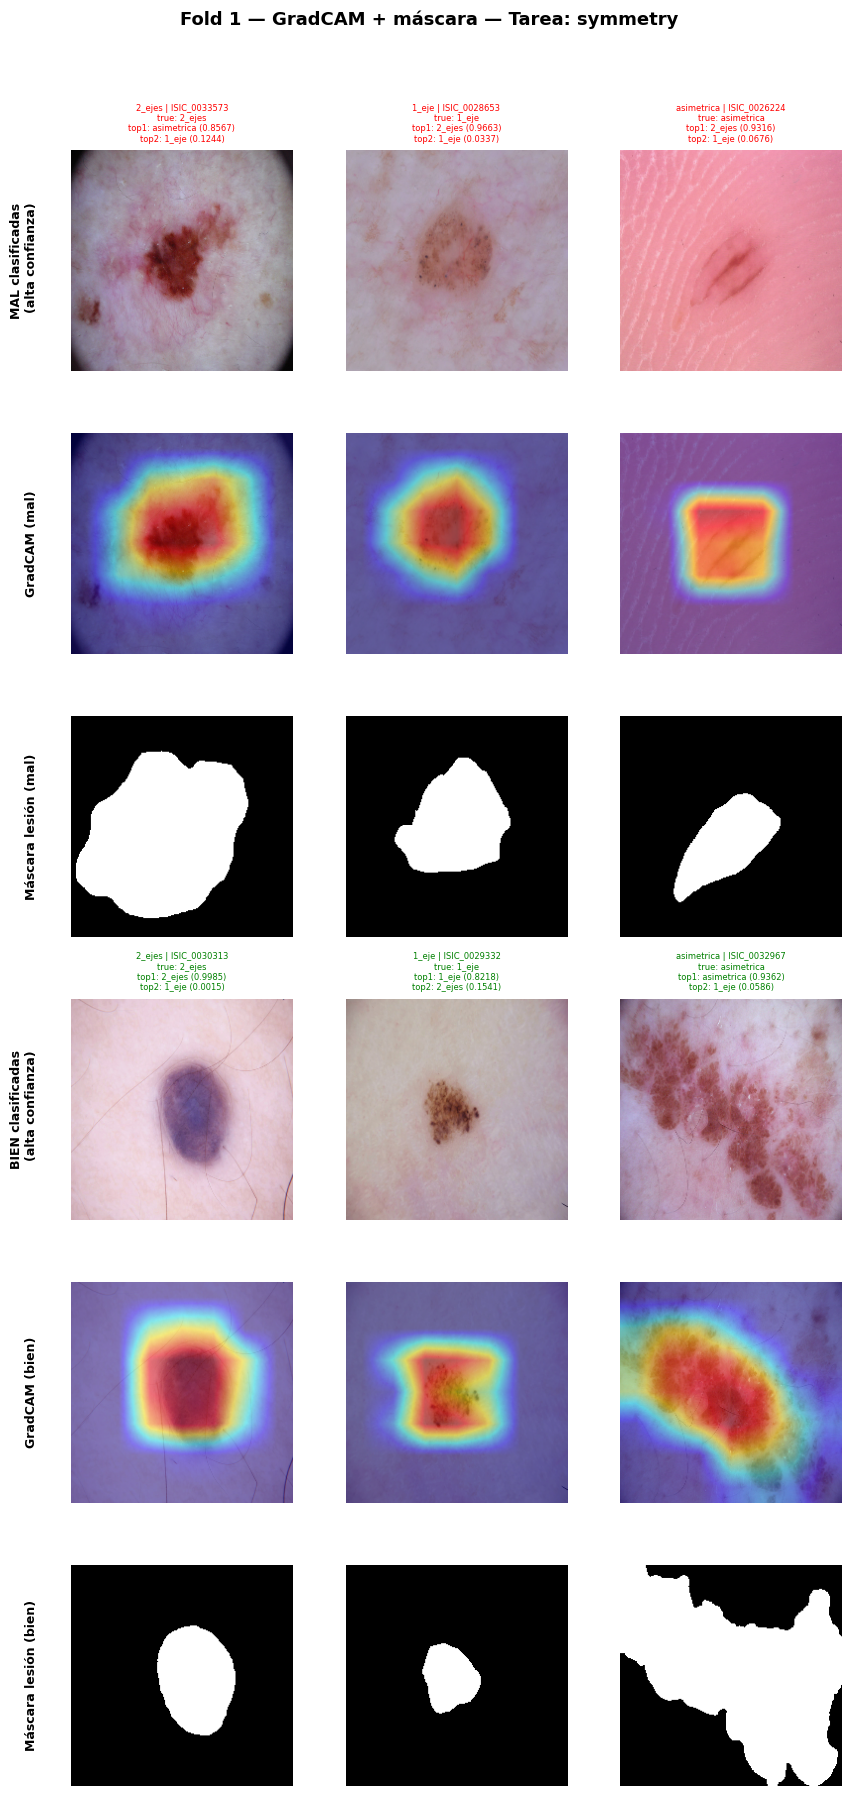


Imágenes GradCAM guardadas en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold/gradcam


In [10]:
import cv2

#Parámetros 
GRADCAM_LAYER   = "Conv_1"
SEG_MASKS_PATH  = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/binary_seg/HAM10000_segmentations_lesion_tschandl"

#Mejor fold 
best_metric_col = f"{TASK_NAME}_balanced_acc"
best_fold_idx   = int(df_metrics[best_metric_col].idxmax()) + 1
print(f"Usando fold {best_fold_idx}  "
      f"({best_metric_col}={df_metrics[best_metric_col].max():.4f})")

fold_dir_best = EXP_DIR / f"fold_{best_fold_idx}"
weights_path  = fold_dir_best / "best_weights"

#Reconstruir modelo y cargar pesos
backbone_gc, base_gc = build_model()
for imgs, _ in test_ds.take(1):
    _ = backbone_gc(imgs[:1], training=False)
if (fold_dir_best / "best_weights.index").exists():
    backbone_gc.load_weights(str(weights_path))
    print(f"Pesos cargados desde {weights_path}")
else:
    print(f"[AVISO] No se encontró {weights_path}.index")


#GradCAM 
def make_gradcam_heatmap(img_array, model, class_idx):
    mobilenet_sub = model.get_layer("mobilenetv2_1.00_224")
    mobilenet_dual = tf.keras.Model(
        inputs=mobilenet_sub.input,
        outputs=[mobilenet_sub.get_layer("Conv_1").output, mobilenet_sub.output],
    )
    gap_layer    = model.get_layer("gap")
    shared_dense = model.get_layer("shared_dense")
    shared_drop  = model.get_layer("shared_dropout")
    head         = model.get_layer(f"head_{TASK_NAME}")

    with tf.GradientTape() as tape:
        conv_outputs, mobilenet_final = mobilenet_dual(img_array, training=False)
        x           = gap_layer(mobilenet_final)
        x           = shared_dense(x)
        x           = shared_drop(x, training=False)
        predictions = head(x)
        loss        = predictions[:, class_idx]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_heatmap(img_orig, heatmap, alpha=0.45):
    heatmap_r = cv2.resize(heatmap, (img_orig.shape[1], img_orig.shape[0]))
    colored   = cv2.applyColorMap((heatmap_r * 255).astype(np.uint8), cv2.COLORMAP_JET)
    colored   = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    return (alpha * colored + (1 - alpha) * img_orig).astype(np.uint8)


def load_img_for_gradcam(filepath):
    raw      = tf.io.read_file(filepath)
    raw      = tf.image.decode_image(raw, channels=3, expand_animations=False)
    raw      = tf.image.resize(raw, IMG_SIZE)
    img_orig = raw.numpy().astype(np.uint8)
    img_pre  = tf.keras.applications.mobilenet_v2.preprocess_input(tf.cast(raw, tf.float32))
    return img_orig, tf.expand_dims(img_pre, 0)


def load_lesion_mask(image_id):
    """Carga la máscara binaria de la lesión y la redimensiona a IMG_SIZE."""
    mask_path = os.path.join(SEG_MASKS_PATH, f"{image_id}_segmentation.png")
    if not os.path.exists(mask_path):
        return None
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    return mask


#Plot matriz por clase (con máscaras) 
def plot_gradcam_by_class(df_test, y_true_int, y_pred_int, y_pred_proba,
                           backbone_model, class_names, fold_label="", save_dir=None):
    """
    Matriz 6 x n_clases:
      Fila 1: MAL clasificadas (imagen original)
      Fila 2: GradCAM overlay (mal)
      Fila 3: Máscara lesión (mal)
      Fila 4: BIEN clasificadas (imagen original)
      Fila 5: GradCAM overlay (bien)
      Fila 6: Máscara lesión (bien)
    """
    n_cls = len(class_names)
    fig, axes = plt.subplots(6, n_cls, figsize=(3 * n_cls, 18))
    if n_cls == 1:
        axes = axes[:, np.newaxis]

    fig.suptitle(f"{fold_label} GradCAM + máscara - Tarea: {TASK_NAME}",
                 fontsize=13, fontweight="bold", y=0.995)

    for ci, cname in enumerate(class_names):
        #MAL clasificadas 
        mask_bad = (y_true_int == ci) & (y_pred_int != ci)
        idx_bad  = np.where(mask_bad)[0]
        if len(idx_bad) > 0:
            confidences = y_pred_proba[idx_bad, y_pred_int[idx_bad]]
            best        = idx_bad[np.argmax(confidences)]
            top2_idx    = np.argsort(y_pred_proba[best])[::-1][:2]
            top1_cls    = class_names[top2_idx[0]]
            top2_cls    = class_names[top2_idx[1]]
            top1_prob   = y_pred_proba[best, top2_idx[0]]
            top2_prob   = y_pred_proba[best, top2_idx[1]]

            filepath    = df_test.iloc[best]["filepath"]
            image_id    = df_test.iloc[best]["image_id"]
            img_orig, img_pre = load_img_for_gradcam(filepath)
            heatmap  = make_gradcam_heatmap(img_pre, backbone_model, class_idx=int(top2_idx[0]))
            overlay  = overlay_heatmap(img_orig, heatmap)
            seg_mask = load_lesion_mask(image_id)

            axes[0, ci].imshow(img_orig)
            axes[0, ci].set_title(
                f"{cname} | {image_id}\ntrue: {cname}\n"
                f"top1: {top1_cls} ({top1_prob:.4f})\n"
                f"top2: {top2_cls} ({top2_prob:.4f})",
                fontsize=6, color="red")
            axes[1, ci].imshow(overlay)
            if seg_mask is not None:
                axes[2, ci].imshow(seg_mask, cmap="gray")
            else:
                axes[2, ci].text(0.5, 0.5, "máscara\nno disponible",
                                 ha="center", va="center", fontsize=7)
        else:
            for r in range(3):
                axes[r, ci].text(0.5, 0.5, f"{cname}\nNo hay\nmalas",
                                 ha="center", va="center", fontsize=8)

        #BIEN clasificadas 
        mask_good = (y_true_int == ci) & (y_pred_int == ci)
        idx_good  = np.where(mask_good)[0]
        if len(idx_good) > 0:
            confidences = y_pred_proba[idx_good, ci]
            best        = idx_good[np.argmax(confidences)]
            top2_idx    = np.argsort(y_pred_proba[best])[::-1][:2]
            top1_cls    = class_names[top2_idx[0]]
            top2_cls    = class_names[top2_idx[1]]
            top1_prob   = y_pred_proba[best, top2_idx[0]]
            top2_prob   = y_pred_proba[best, top2_idx[1]]

            filepath    = df_test.iloc[best]["filepath"]
            image_id    = df_test.iloc[best]["image_id"]
            img_orig, img_pre = load_img_for_gradcam(filepath)
            heatmap  = make_gradcam_heatmap(img_pre, backbone_model, class_idx=int(ci))
            overlay  = overlay_heatmap(img_orig, heatmap)
            seg_mask = load_lesion_mask(image_id)

            axes[3, ci].imshow(img_orig)
            axes[3, ci].set_title(
                f"{cname} | {image_id}\ntrue: {cname}\n"
                f"top1: {top1_cls} ({top1_prob:.4f})\n"
                f"top2: {top2_cls} ({top2_prob:.4f})",
                fontsize=6, color="green")
            axes[4, ci].imshow(overlay)
            if seg_mask is not None:
                axes[5, ci].imshow(seg_mask, cmap="gray")
            else:
                axes[5, ci].text(0.5, 0.5, "máscara\nno disponible",
                                 ha="center", va="center", fontsize=7)
        else:
            for r in range(3, 6):
                axes[r, ci].text(0.5, 0.5, f"{cname}\nNo hay\nbuenas",
                                 ha="center", va="center", fontsize=8)

        for r in range(6):
            axes[r, ci].axis("off")

    row_labels = [
        "MAL clasificadas\n(alta confianza)",
        "GradCAM (mal)",
        "Máscara lesión (mal)",
        "BIEN clasificadas\n(alta confianza)",
        "GradCAM (bien)",
        "Máscara lesión (bien)",
    ]
    for r, label in enumerate(row_labels):
        axes[r, 0].text(-0.15, 0.5, label, transform=axes[r, 0].transAxes,
                        fontsize=9, rotation=90, va="center", ha="right",
                        fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_dir:
        out = Path(save_dir) / f"gradcam_{TASK_NAME}_by_class.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  Guardado: {out}")
    plt.show()


#Recomputar predicciones 
print("\nRecomputando predicciones del fold seleccionado...")
y_pred_proba_gc = backbone_gc.predict(test_ds, verbose=0)
y_pred_int_gc   = np.argmax(y_pred_proba_gc, axis=1)

gradcam_dir = EXP_DIR / "gradcam"
gradcam_dir.mkdir(exist_ok=True)
fold_label  = f"Fold {best_fold_idx} -"

print(f"\n=== GradCAM - Tarea: {TASK_NAME.upper()} (matriz por clase con máscaras) ===")
plot_gradcam_by_class(
    df_test, y_test_int, y_pred_int_gc, y_pred_proba_gc,
    backbone_gc, class_names=class_names,
    fold_label=fold_label, save_dir=str(gradcam_dir))

print(f"\nImágenes GradCAM guardadas en: {gradcam_dir.resolve()}")

In [11]:
#Recomputar métricas añadiendo precision y recall 
print("Recomputando métricas con precision/recall macro desde pesos guardados...\n")

updated_rows = []
for fold_idx in range(1, N_FOLDS + 1):
    fold_dir_k = EXP_DIR / f"fold_{fold_idx}"
    weights_k  = fold_dir_k / "best_weights"

    if not (fold_dir_k / "best_weights.index").exists():
        print(f"  [AVISO] fold {fold_idx}: no hay pesos, se salta")
        continue

    tf.keras.backend.clear_session()
    model_k, base_k = build_model()
    for imgs, _ in test_ds.take(1):
        _ = model_k(imgs[:1], training=False)
    model_k.load_weights(str(weights_k))

    y_pred_proba = model_k.predict(test_ds, verbose=0)
    y_pred_int   = np.argmax(y_pred_proba, axis=1)

    # Recuperar la fila existente y añadir las nuevas columnas
    row = df_metrics[df_metrics["fold"] == fold_idx].iloc[0].to_dict()
    row[f"{TASK_NAME}_precision_macro"] = float(
        precision_score(y_test_int, y_pred_int, average="macro", zero_division=0))
    row[f"{TASK_NAME}_recall_macro"] = float(
        recall_score(y_test_int, y_pred_int, average="macro", zero_division=0))

    updated_rows.append(row)
    print(f"  fold {fold_idx}: precision={row[f'{TASK_NAME}_precision_macro']:.4f}  "
          f"recall={row[f'{TASK_NAME}_recall_macro']:.4f}")

#Reconstruir df_metrics y summary 
df_metrics = pd.DataFrame(updated_rows)
df_metrics.to_csv(EXP_DIR / "all_folds_metrics.csv", index=False)

numeric  = [c for c in df_metrics.columns
            if c != "fold" and pd.api.types.is_numeric_dtype(df_metrics[c])]
summary  = df_metrics[numeric].agg(["mean", "median", "std"]).T
summary.columns = ["mean", "median", "std"]
summary["mean±std"] = summary.apply(
    lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}", axis=1)
summary.to_csv(EXP_DIR / "summary_mean_median_std.csv")

print("\ndf_metrics y summary actualizados")
print("\nNuevas métricas en summary:")
print(summary.loc[[i for i in summary.index if "precision" in i or "recall" in i]])

Recomputando métricas con precision/recall macro desde pesos guardados...

  fold 1: precision=0.5553  recall=0.6077
  fold 2: precision=0.5224  recall=0.5722
  fold 3: precision=0.5472  recall=0.5711
  fold 4: precision=0.5209  recall=0.5756
  fold 5: precision=0.5180  recall=0.5895

✓ df_metrics y summary actualizados

Nuevas métricas en summary:
                              mean    median       std         mean±std
symmetry_precision_macro  0.532759  0.522391  0.017207  0.5328 ± 0.0172
symmetry_recall_macro     0.583206  0.575601  0.015534  0.5832 ± 0.0155


In [12]:
def build_final_pdf():
    pdf_path    = EXP_DIR / "FINAL_REPORT.pdf"
    plots_dir   = EXP_DIR / "training_plots_cv"
    gradcam_dir = EXP_DIR / "gradcam"

    with PdfPages(pdf_path) as pdf:

        #Portada 
        fig = plt.figure(figsize=(11, 8.5))
        fig.text(0.5, 0.92, f"STL ({TASK_NAME}) - Reporte final",
                 ha="center", fontsize=20, fontweight="bold")
        fig.text(0.5, 0.87, f"MobileNetV2  |  CUT_LAYER={CUT_LAYER}  |  K={N_FOLDS} folds",
                 ha="center", fontsize=13, style="italic")
        fig.text(0.5, 0.83, EXP_DIR.name,
                 ha="center", fontsize=9, family="monospace")

        info  = "Arquitectura: MobileNetV2 + GAP + shared_dense(256) + dropout(0.3) + 1 cabeza\n\n"
        info += f"Tarea: {TASK_NAME} ({NUM_CLASSES} clases)\n"
        info += f"  Clases: {', '.join(class_names)}\n\n"
        info += "Configuracion de entrenamiento:\n"
        info += f"  - Warmup:       LR={WARMUP_LR}, epochs max={WARMUP_EPOCHS}, patience ES=7, patience LR=3\n"
        info += f"  - Fine-tuning:  LR={FT_LR}, epochs max={FT_EPOCHS}, patience ES=8, patience LR=3\n"
        info += f"  - Batch size: {BATCH_SIZE}, image size: {IMG_SIZE[0]}x{IMG_SIZE[1]}\n\n"
        info += "Protocolo: transfer learning estandar (TF/Keras oficial, CS231n)\n"
        info += "  - Fase 1: heads entrenables con LR alto\n"
        info += "  - Fase 2: backbone descongelado con LR reducido\n\n"
        info += "Class weights balanceados aplicados a la tarea\n\n"
        info += "Dataset:\n"
        info += f"  - train+val (CV): {len(df_trainval)} imagenes\n"
        info += f"  - test (fijo):    {len(df_test)} imagenes\n\n"
        info += f"Tiempo total experimento: {t_exp_total/60:.1f} min"

        fig.text(0.08, 0.75, info, fontsize=9, family="monospace", va="top")
        plt.axis("off")
        pdf.savefig(fig); plt.close(fig)

        #Resumen ejecutivo 
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.axis("off")
        ax.set_title(f"Resumen ejecutivo - metricas de clasificacion ({N_FOLDS} folds)",
                     fontsize=14, fontweight="bold", pad=20)

        task_metrics_list = [
            (f"{TASK_NAME}_acc",             "Accuracy"),
            (f"{TASK_NAME}_balanced_acc",    "Balanced Acc"),
            (f"{TASK_NAME}_precision_macro", "Precision macro"),   
            (f"{TASK_NAME}_recall_macro",    "Recall macro"),      
            (f"{TASK_NAME}_f1_macro",        "F1 macro"),
            (f"{TASK_NAME}_auc_macro",       "AUC macro"),
            (f"{TASK_NAME}_kappa",           "Kappa"),
        ]

        

        rows       = []
        row_colors = []
        rows.append([f"{TASK_NAME.capitalize()} ({NUM_CLASSES} clases)", "", "", ""])
        row_colors.append(["#d9e1f2"] * 4)
        for metric_key, label in task_metrics_list:
            if metric_key in summary.index:
                mean   = summary.loc[metric_key, "mean"]
                median = summary.loc[metric_key, "median"]
                std    = summary.loc[metric_key, "std"]
                rows.append([f"  {label}",
                             f"{mean:.4f}",
                             f"{median:.4f}",
                             f"{std:.4f}"])
                if metric_key == "auc_melanoma":
                    row_colors.append(["#fce4d6"] * 4)
                else:
                    row_colors.append(["white"] * 4)

        tbl = ax.table(
            cellText=rows,
            colLabels=["Metrica", "Media", "Mediana", "Desv. tipica"],
            loc="center",
            cellLoc="left",
            cellColours=row_colors,
            colColours=["#305496"] * 4,
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(10)
        tbl.scale(1, 1.8)
        for j in range(4):
            tbl[(0, j)].set_text_props(color="white", fontweight="bold")

        pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        #Tabla resumen completa 
        fig, ax = plt.subplots(figsize=(13, 8.5))
        ax.axis("off")
        ax.set_title(f"Resumen completo entre folds (K={N_FOLDS}) - mean / median / std",
                     fontsize=14, fontweight="bold", pad=20)
        tbl = ax.table(
            cellText=[[i, f"{r['mean']:.4f}", f"{r['median']:.4f}", f"{r['std']:.4f}"]
                      for i, r in summary.iterrows()],
            colLabels=["metrica", "mean", "median", "std"],
            loc="center", cellLoc="left",
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1, 1.4)
        pdf.savefig(fig); plt.close(fig)

        #Tabla metricas por fold 
        fig, ax = plt.subplots(figsize=(14, 8.5))
        ax.axis("off")
        ax.set_title(f"Metricas por fold - STL {TASK_NAME}",
                     fontsize=14, fontweight="bold", pad=20)
        cols = [
            "fold",
            f"{TASK_NAME}_acc", f"{TASK_NAME}_balanced_acc",
            f"{TASK_NAME}_f1_macro", f"{TASK_NAME}_auc_macro", f"{TASK_NAME}_kappa",
        ]
        if TASK_NAME == "disease" and "auc_melanoma" in df_metrics.columns:
            cols.append("auc_melanoma")
        cols += ["time_total_s", "epochs_warmup", "epochs_ft"]

        df_show = df_metrics[cols].copy()
        for c in df_show.columns:
            if c != "fold":
                df_show[c] = df_show[c].round(4)
        tbl = ax.table(
            cellText=df_show.values.tolist(),
            colLabels=cols, loc="center", cellLoc="center",
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(7); tbl.scale(1, 1.4)
        pdf.savefig(fig); plt.close(fig)

        #Grafica conjunta warmup + FT 
        p_combined = plots_dir / "combined_full_training.png"
        if p_combined.exists():
            fig = plt.figure(figsize=(14, 5))
            plt.imshow(plt.imread(str(p_combined))); plt.axis("off")
            plt.title("Entrenamiento completo - warmup + fine-tuning (mean ± std)",
                      fontsize=12, fontweight="bold")
            pdf.savefig(fig); plt.close(fig)

        #Fases separadas 
        for phase, title in [("phase1_warmup",   "Warmup - loss/acc (mean ± std)"),
                              ("phase2_finetune", "Fine-tuning - loss/acc (mean ± std)")]:
            p = plots_dir / f"{phase}_cv_mean_std.png"
            if p.exists():
                fig = plt.figure(figsize=(13, 5))
                plt.imshow(plt.imread(str(p))); plt.axis("off")
                plt.title(title, fontsize=12, fontweight="bold")
                pdf.savefig(fig); plt.close(fig)

        #Matriz de confusion agregada 
        p = EXP_DIR / f"confusion_matrix_{TASK_NAME}_aggregated.png"
        if p.exists():
            fig = plt.figure(figsize=(14, 6))
            plt.imshow(plt.imread(str(p))); plt.axis("off")
            plt.title(f"Matriz de confusion agregada - {TASK_NAME} ({NUM_CLASSES} clases)",
                      fontsize=12, fontweight="bold")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        #GradCAM por clase 
        p = gradcam_dir / f"gradcam_{TASK_NAME}_by_class.png"
        if p.exists():
            img_data = plt.imread(str(p))
            h, w     = img_data.shape[:2]
            fig = plt.figure(figsize=(11, 11 * h / w))
            plt.imshow(img_data); plt.axis("off")
            plt.title(f"GradCAM buenas/malas por clase - {TASK_NAME}",
                      fontsize=12, fontweight="bold")
            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        #Detalle por fold 
        for k in range(1, N_FOLDS + 1):
            fd = EXP_DIR / f"fold_{k}"

            p = fd / f"confusion_matrix_{TASK_NAME}.png"
            if p.exists():
                fig = plt.figure(figsize=(10, 7))
                plt.imshow(plt.imread(str(p))); plt.axis("off")
                plt.title(f"Fold {k} - Matriz confusion - {TASK_NAME}",
                          fontsize=11, fontweight="bold")
                pdf.savefig(fig); plt.close(fig)

            rpt = fd / f"classification_report_{TASK_NAME}.txt"
            if rpt.exists():
                fig = plt.figure(figsize=(11, 8.5)); plt.axis("off")
                plt.title(f"Fold {k} - Classification report - {TASK_NAME}",
                          fontsize=11, fontweight="bold", loc="left")
                plt.text(0.05, 0.95, rpt.read_text(),
                         fontsize=10, family="monospace", va="top")
                pdf.savefig(fig); plt.close(fig)

    print(f"PDF guardado en: {pdf_path.resolve()}")
    return pdf_path

_ = build_final_pdf()

PDF guardado en: /home/marc/MARIADELMAR_EXPERIMENTS/STL_Symmetry_experimentos/MobileNetV2_STL/exp_2026-04-26_18-08_symmetry_CUT0_5fold/FINAL_REPORT.pdf
